In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib


In [74]:
df = pd.read_csv('income_evaluation.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              32561 non-null  int64
 1    workclass       32561 non-null  str  
 2    fnlwgt          32561 non-null  int64
 3    education       32561 non-null  str  
 4    education-num   32561 non-null  int64
 5    marital-status  32561 non-null  str  
 6    occupation      32561 non-null  str  
 7    relationship    32561 non-null  str  
 8    race            32561 non-null  str  
 9    sex             32561 non-null  str  
 10   capital-gain    32561 non-null  int64
 11   capital-loss    32561 non-null  int64
 12   hours-per-week  32561 non-null  int64
 13   native-country  32561 non-null  str  
 14   income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [76]:
df = df.rename(columns=lambda x: x.strip().replace('-', '_').title())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       32561 non-null  str  
 2   Fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_Num   32561 non-null  int64
 5   Marital_Status  32561 non-null  str  
 6   Occupation      32561 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_Gain    32561 non-null  int64
 11  Capital_Loss    32561 non-null  int64
 12  Hours_Per_Week  32561 non-null  int64
 13  Native_Country  32561 non-null  str  
 14  Income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [77]:
# removing irrelavant columns
df.drop(['Fnlwgt','Education_Num','Relationship','Race','Native_Country'], axis=1, inplace=True)

In [78]:
# Removing leading & trailing spaces from data
df = df.apply(lambda x: x.str.strip() if x.dtype == "str" else x)

In [79]:
# Removed entries with '?'
#df = df[((df['Workclass'] != '?') & (df['Occupation'] != '?'))]
df.loc[df['Workclass'] == '?', 'Workclass'] = df['Workclass'].mode().iloc[0]
df.loc[df['Occupation'] == '?', 'Occupation'] = df['Occupation'].mode().iloc[0]

In [80]:
df.isnull().sum()

Age               0
Workclass         0
Education         0
Marital_Status    0
Occupation        0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_Per_Week    0
Income            0
dtype: int64

In [83]:
df.duplicated().sum()

np.int64(5978)

In [84]:
df.drop_duplicates()

,Age,Workclass,Education,Marital_Status,Occupation,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Male,2174,0,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Male,0,0,13,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Male,0,0,40,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Male,0,0,40,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Female,0,0,40,<=50K
...,...,...,...,...,...,...,...,...,...,...
32554,53,Private,Masters,Married-civ-spouse,Exec-managerial,Male,0,0,40,>50K
32555,22,Private,Some-college,Never-married,Protective-serv,Male,0,0,40,<=50K
32556,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Female,0,0,38,<=50K
32558,58,Private,HS-grad,Widowed,Adm-clerical,Female,0,0,40,<=50K


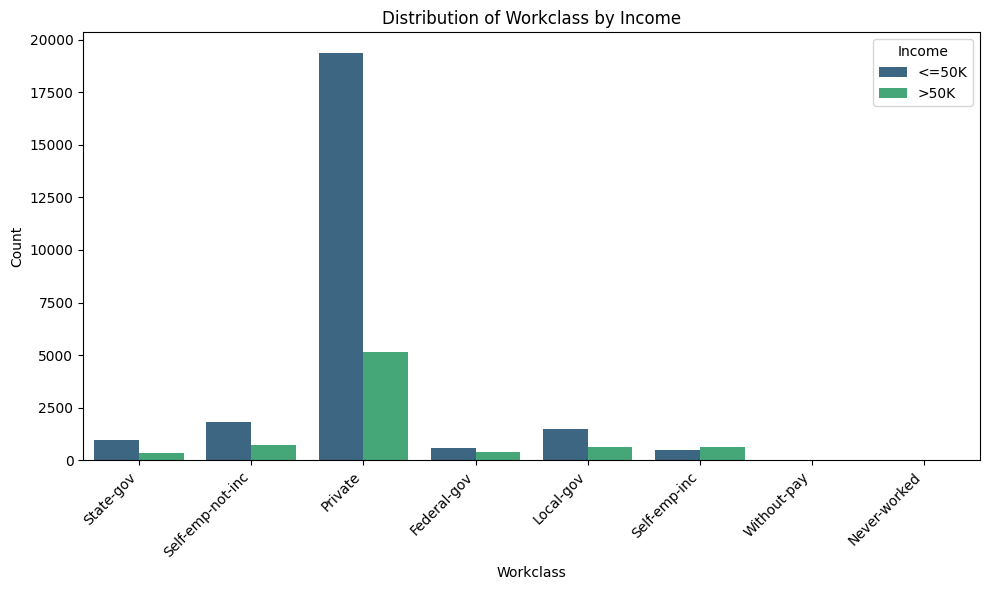

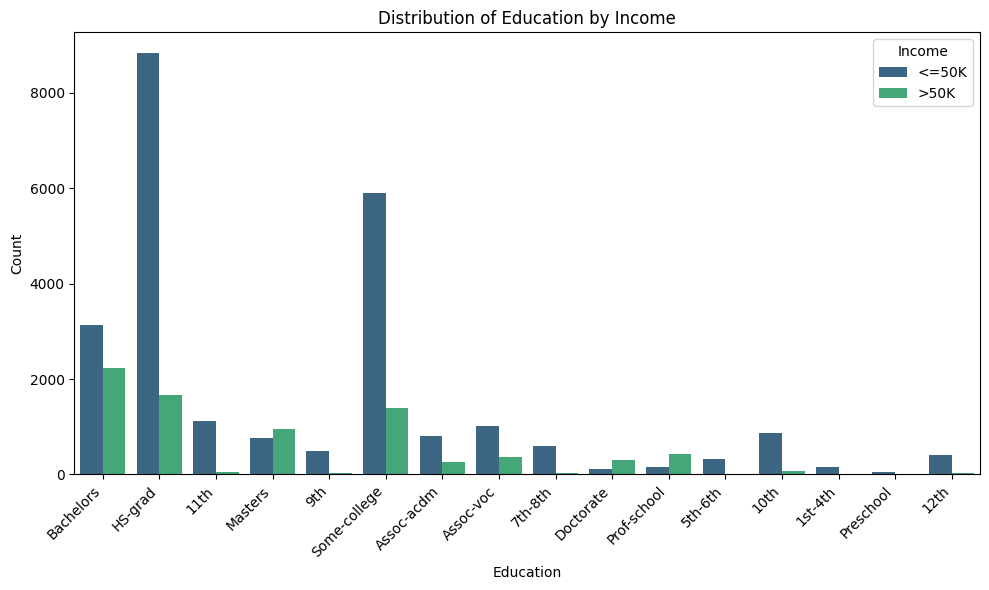

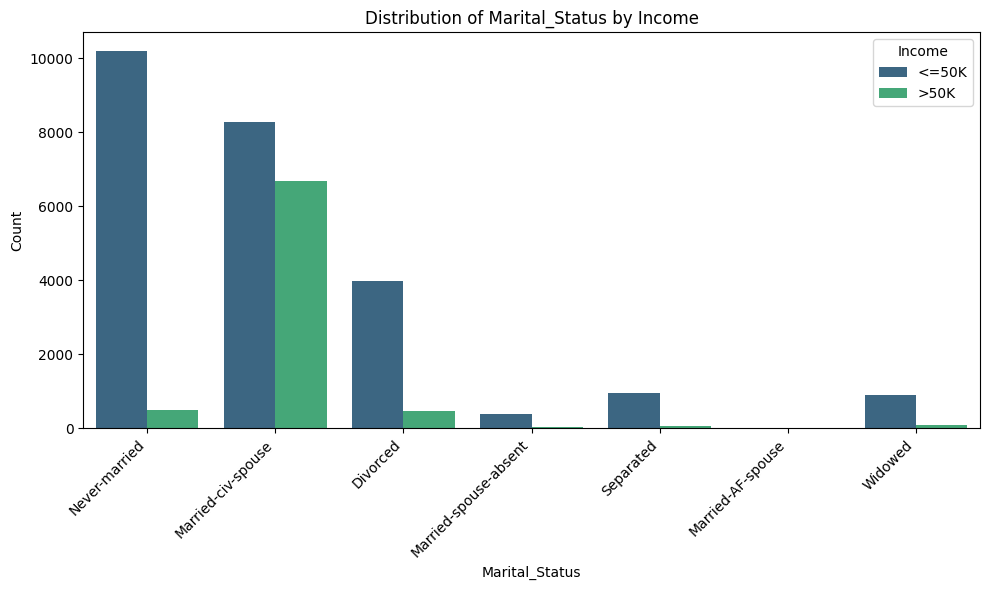

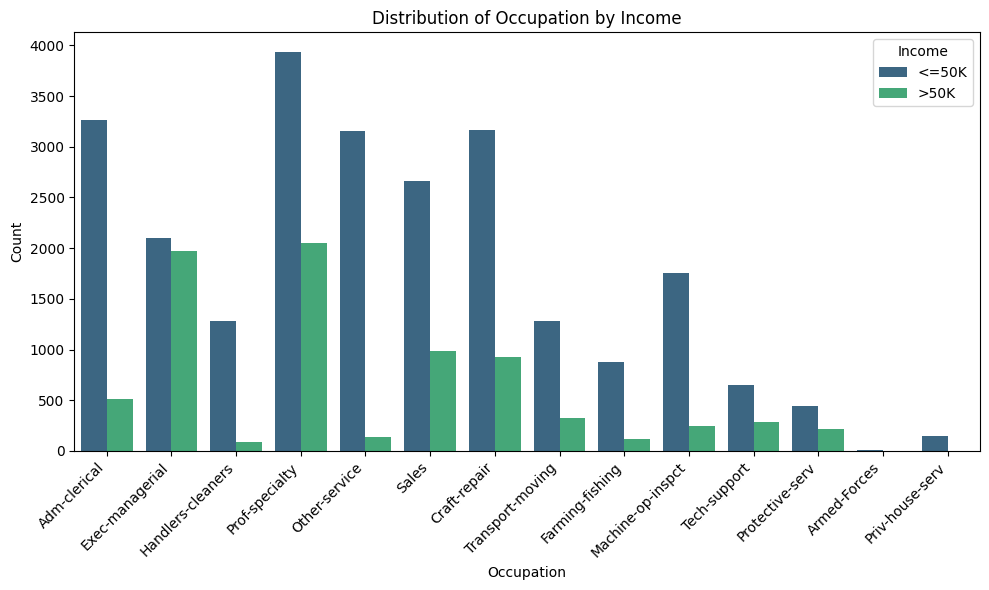

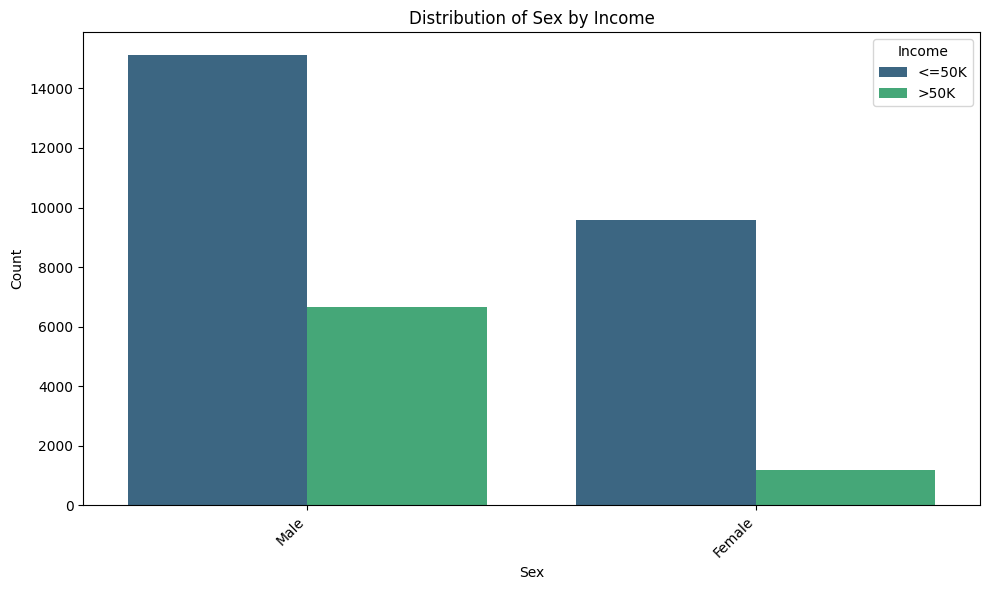

In [85]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    if col == 'Income':
        continue
    
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Income', palette='viridis')
    plt.title(f'Distribution of {col} by Income')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [86]:
categorical_cols

Index(['Workclass', 'Education', 'Marital_Status', 'Occupation', 'Sex',
       'Income'],
      dtype='str')

In [87]:
# convert categorical to numeric
label_encoders = {}

for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])
    print({label: index for index, label in enumerate(label_encoders[col].classes_)})

{'Federal-gov': 0, 'Local-gov': 1, 'Never-worked': 2, 'Private': 3, 'Self-emp-inc': 4, 'Self-emp-not-inc': 5, 'State-gov': 6, 'Without-pay': 7}
{'10th': 0, '11th': 1, '12th': 2, '1st-4th': 3, '5th-6th': 4, '7th-8th': 5, '9th': 6, 'Assoc-acdm': 7, 'Assoc-voc': 8, 'Bachelors': 9, 'Doctorate': 10, 'HS-grad': 11, 'Masters': 12, 'Preschool': 13, 'Prof-school': 14, 'Some-college': 15}
{'Divorced': 0, 'Married-AF-spouse': 1, 'Married-civ-spouse': 2, 'Married-spouse-absent': 3, 'Never-married': 4, 'Separated': 5, 'Widowed': 6}
{'Adm-clerical': 0, 'Armed-Forces': 1, 'Craft-repair': 2, 'Exec-managerial': 3, 'Farming-fishing': 4, 'Handlers-cleaners': 5, 'Machine-op-inspct': 6, 'Other-service': 7, 'Priv-house-serv': 8, 'Prof-specialty': 9, 'Protective-serv': 10, 'Sales': 11, 'Tech-support': 12, 'Transport-moving': 13}
{'Female': 0, 'Male': 1}
{'<=50K': 0, '>50K': 1}


In [ ]:
#df = pd.get_dummies(df, columns=categorical_cols, dtype=np.int64, drop_first=True)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       32561 non-null  int64
 2   Education       32561 non-null  int64
 3   Marital_Status  32561 non-null  int64
 4   Occupation      32561 non-null  int64
 5   Sex             32561 non-null  int64
 6   Capital_Gain    32561 non-null  int64
 7   Capital_Loss    32561 non-null  int64
 8   Hours_Per_Week  32561 non-null  int64
 9   Income          32561 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB


In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
Workclass,32561.0,3.094438,1.107194,0.0,3.0,3.0,3.0,7.0
Education,32561.0,10.298210,3.870264,0.0,9.0,11.0,12.0,15.0
Marital_Status,32561.0,2.611836,1.506222,0.0,2.0,2.0,4.0,6.0
Occupation,32561.0,6.138755,3.972708,0.0,3.0,6.0,9.0,13.0
Sex,32561.0,0.669205,0.470506,0.0,0.0,1.0,1.0,1.0
Capital_Gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
Capital_Loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
Hours_Per_Week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0
Income,32561.0,0.240810,0.427581,0.0,0.0,0.0,0.0,1.0


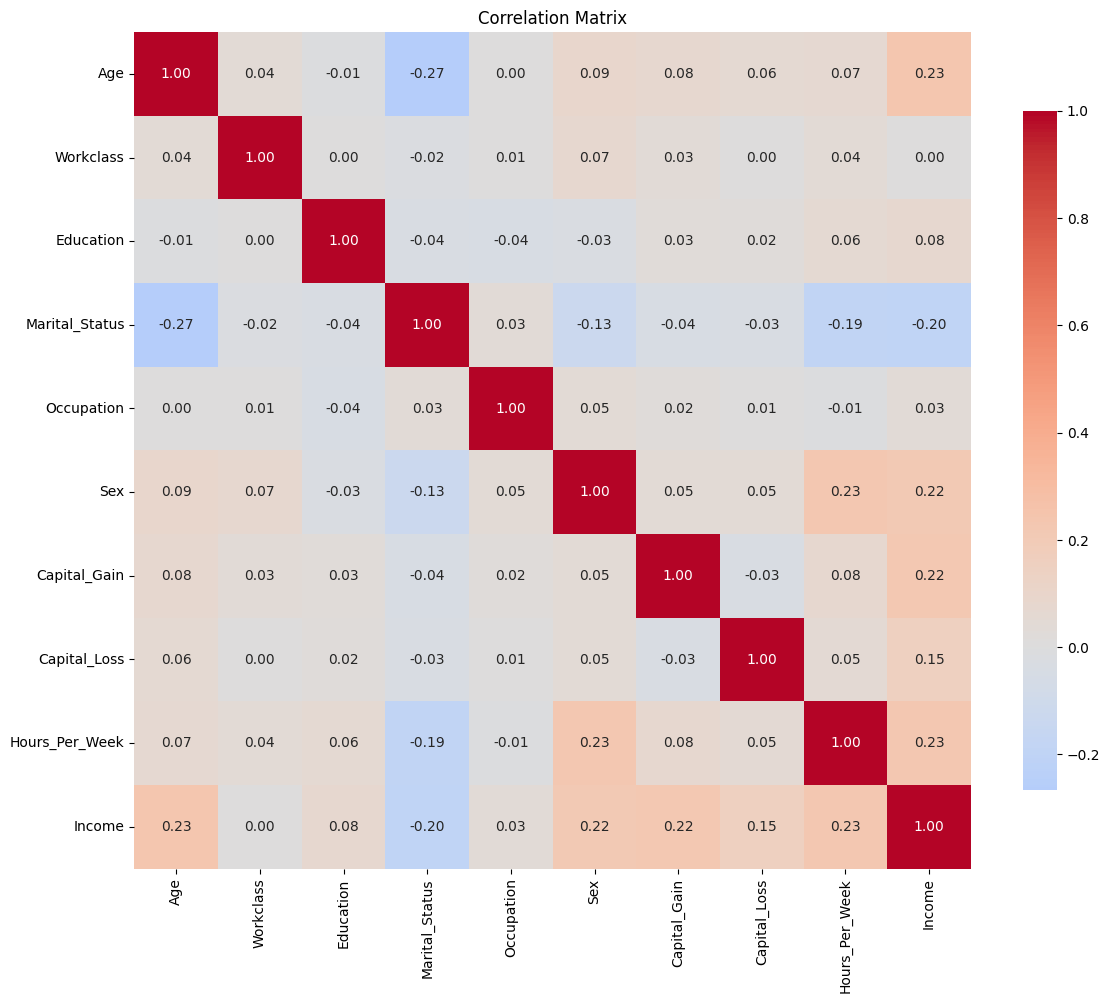

In [90]:
# Calculate and display correlation matrix
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

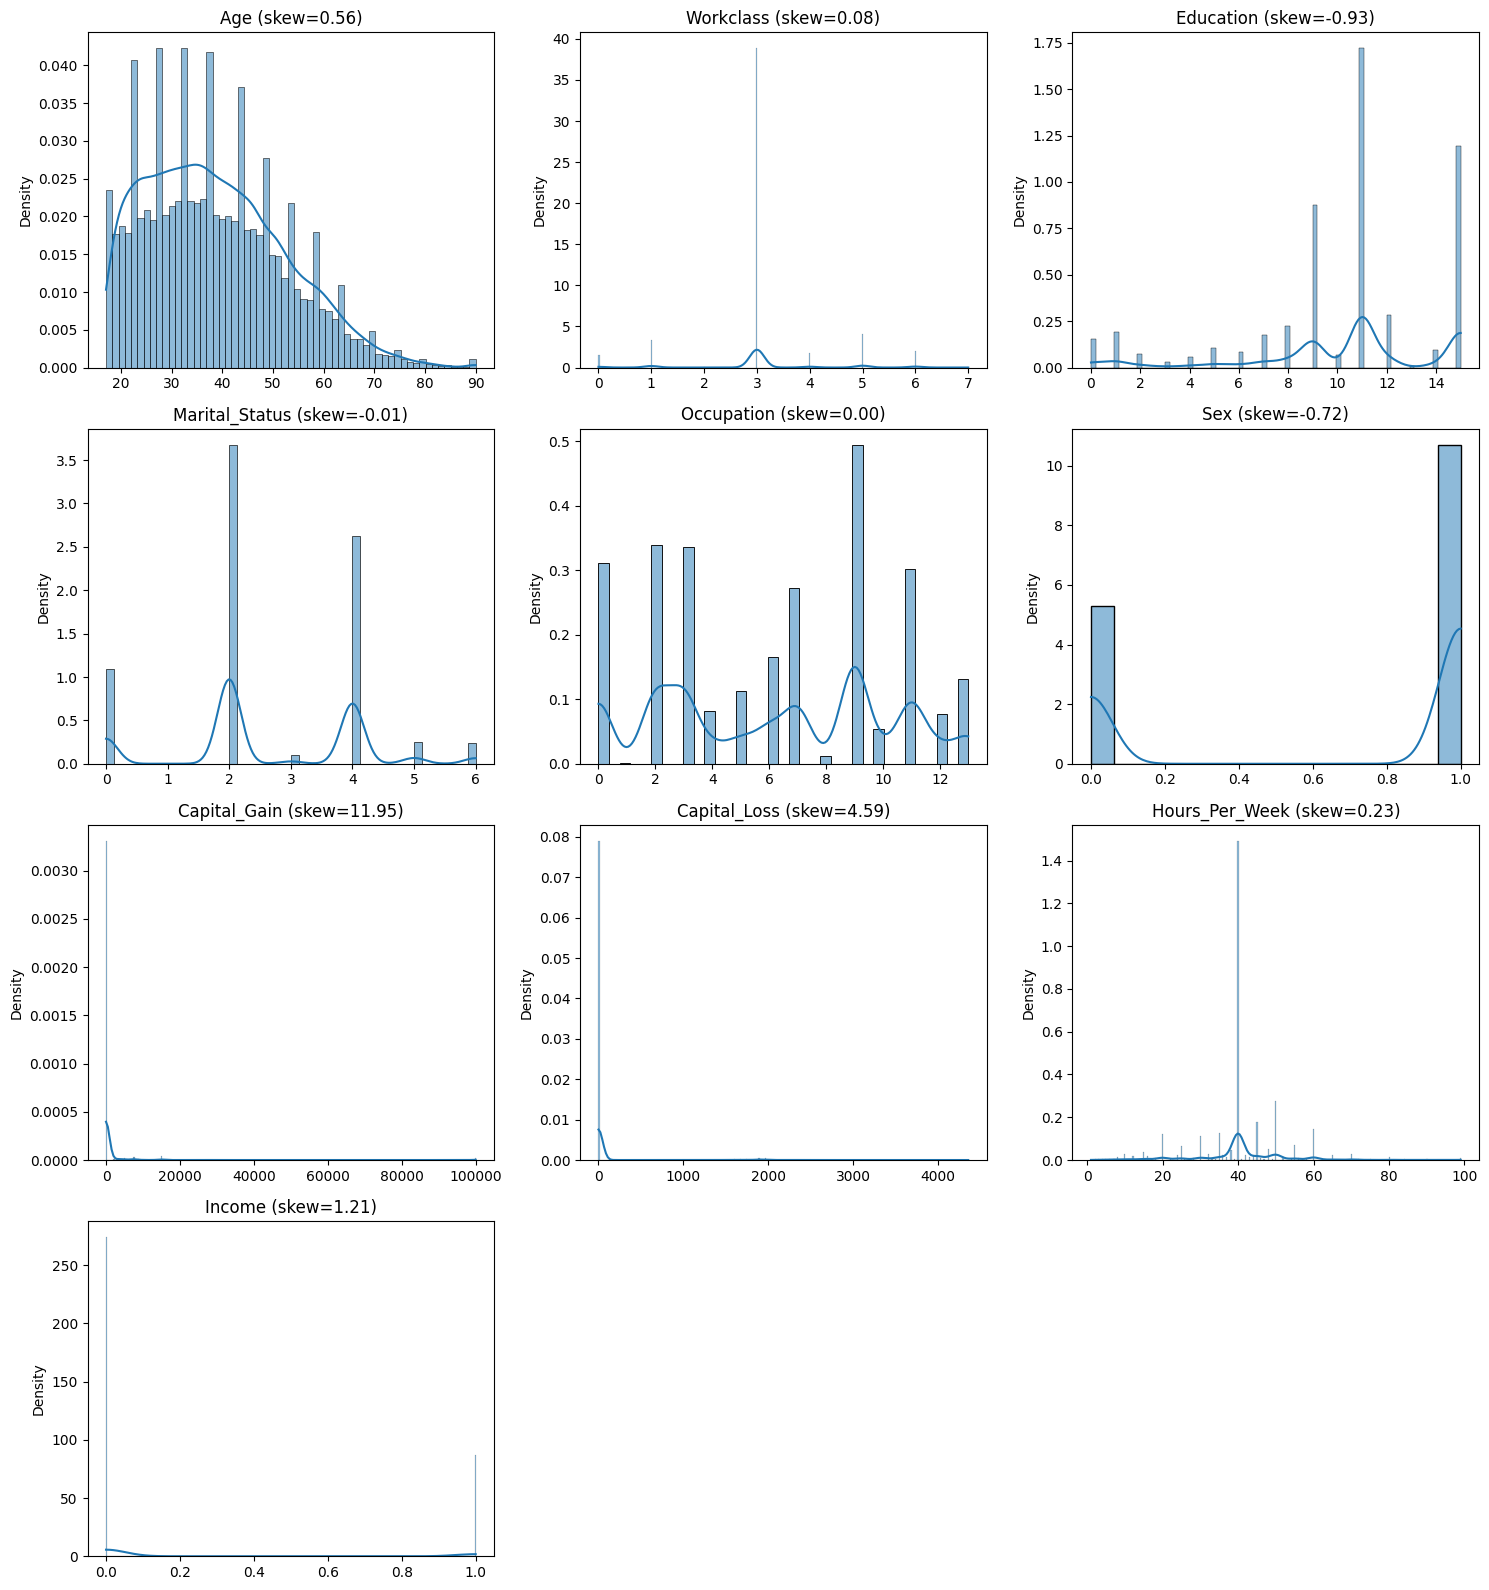

In [91]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols.drop('Income')
n = len(numeric_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], stat='density', color='C0')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# remove any unused axes
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Function to evaluate model performance

In [92]:
training_accuracy_scores = []
testing_accuracy_scores = []

def ClearMetrics():
    training_accuracy_scores.clear()
    testing_accuracy_scores.clear()

def EvaluateModel(p_model, p_x_train, p_y_train, p_x_test, p_y_test):
    p_model.fit(p_x_train, p_y_train)
    
    y_train_pred = p_model.predict(p_x_train)
    accuracy_score_train = accuracy_score(p_y_train, y_train_pred)
    training_accuracy_scores.append(np.round(accuracy_score_train, 4))
    
    y_test_pred = p_model.predict(p_x_test)
    accuracy_score_test = accuracy_score(p_y_test, y_test_pred)
    testing_accuracy_scores.append(np.round(accuracy_score_test, 4))
    

In [93]:
def EndToEndEvaluation(p_models, p_x_train, p_y_train, p_x_test, p_y_test):
    ClearMetrics()
    for l_model in p_models:
        EvaluateModel(l_model, p_x_train, p_y_train, p_x_test, p_y_test)

    results_df = pd.DataFrame({
        'Model': [l_model.__class__.__name__ for l_model in p_models],
        'Train Accuracy': training_accuracy_scores,
        'Test Accuracy': testing_accuracy_scores
    })

    results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
    return results_df

In [94]:
models = [
    LogisticRegression(),
    BernoulliNB(),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    SVC(),
    KNeighborsClassifier(),
    GradientBoostingClassifier(random_state=42),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(random_state=42),
    VotingClassifier(estimators=[
        ('lr', LogisticRegression()),
        ('svc', SVC()),
        ('knn', KNeighborsClassifier()),
        ('rf', DecisionTreeClassifier(random_state=42))
    ])
]

#### Evaluate without EDA

In [95]:
df_without_eda = df.copy()

x = df_without_eda.drop(columns=['Income'])
y = df_without_eda['Income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation without EDA :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)



Model evaluation without EDA :


,Model,Train Accuracy,Test Accuracy
0,XGBClassifier,0.8936,0.8759
1,GradientBoostingClassifier,0.8663,0.8693
2,AdaBoostClassifier,0.8467,0.8508
3,RandomForestClassifier,0.9724,0.8491
4,KNeighborsClassifier,0.8860,0.8431
5,VotingClassifier,0.8303,0.8280
6,DecisionTreeClassifier,0.9724,0.8170
7,SVC,0.8013,0.8065
8,LogisticRegression,0.7937,0.7966
9,BernoulliNB,0.7877,0.7935


#### Perform EDA

In [162]:
df_eda = df.copy()

In [163]:
df_eda.skew()

Age                0.558743
Workclass          0.076469
Education         -0.934042
Marital_Status    -0.013508
Occupation         0.000565
Sex               -0.719293
Capital_Gain      11.953848
Capital_Loss       4.594629
Hours_Per_Week     0.227643
Income             1.212430
dtype: float64

In [164]:
# Handle skewness

pt = PowerTransformer(method='yeo-johnson')

transformed_columns = [col for col in df_eda.columns if col not in ['Income']]
df_eda[transformed_columns] = pt.fit_transform(df_eda[transformed_columns])

df_eda.skew()

Age              -0.013898
Workclass         0.216916
Education        -0.309405
Marital_Status   -0.114212
Occupation       -0.237170
Sex              -0.719293
Capital_Gain      3.016283
Capital_Loss      4.299587
Hours_Per_Week    0.229572
Income            1.212430
dtype: float64

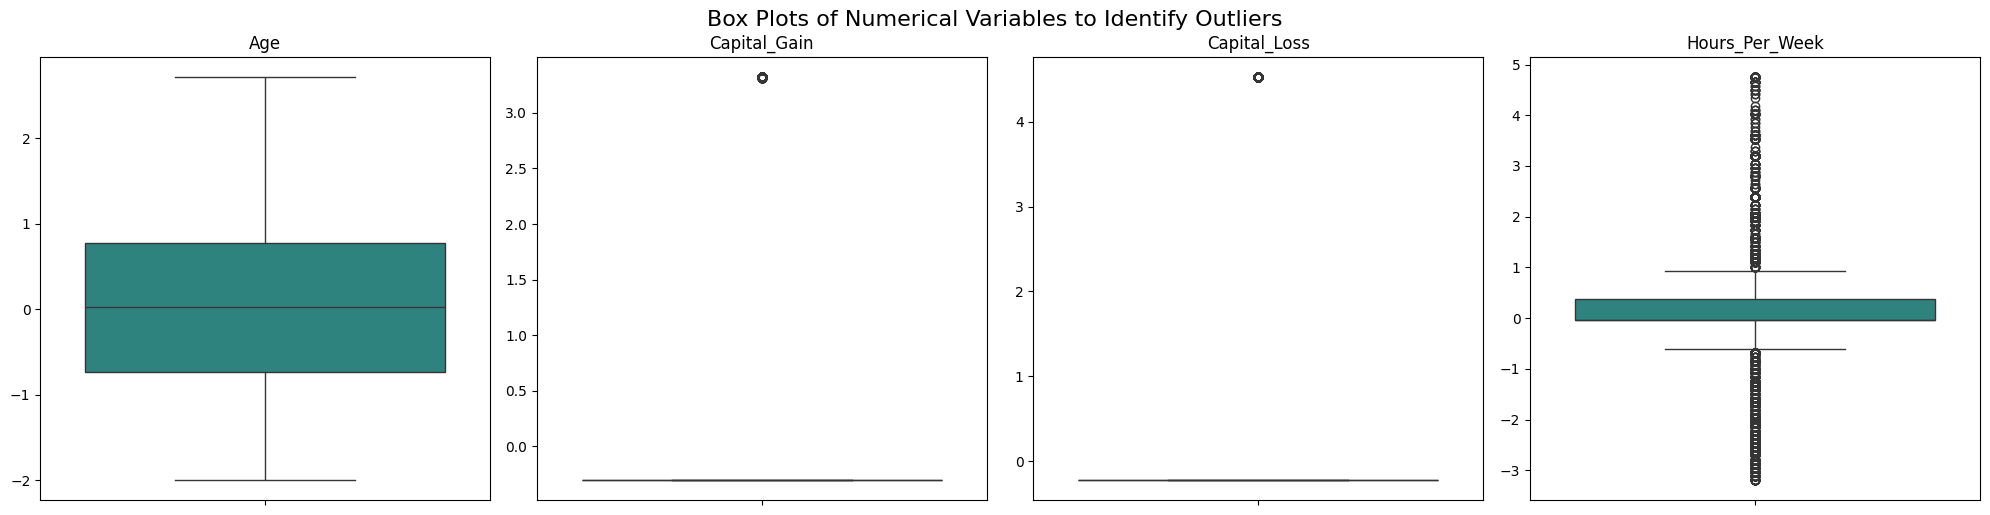

In [165]:
# outlier detection

predictors = [col for col in df_eda.columns if col not in categorical_cols]
num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [166]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,32561.0,1.274399e-15,1.000015,-1.997057,-0.731682,0.028014,0.772168,2.711385
Workclass,32561.0,-3.513325e-16,1.000015,-2.708437,-0.096185,-0.096185,-0.096185,3.629848
Education,32561.0,3.674807e-16,1.000015,-2.161318,-0.477000,0.090500,0.395154,1.387059
Marital_Status,32561.0,1.767574e-17,1.000015,-1.782444,-0.383467,-0.383467,0.919694,2.171796
Occupation,32561.0,8.641471e-17,1.000015,-1.721497,-0.717356,0.060999,0.743428,1.564985
Sex,32561.0,-7.572198e-17,1.000015,-1.422331,-1.422331,0.703071,0.703071,0.703071
Capital_Gain,32561.0,7.201225e-18,1.000015,-0.301425,-0.301425,-0.301425,-0.301425,3.317629
Capital_Loss,32561.0,-1.115099e-16,1.000015,-0.221210,-0.221210,-0.221210,-0.221210,4.520599
Hours_Per_Week,32561.0,-1.514440e-16,1.000015,-3.191989,-0.035570,-0.035570,0.369416,4.745146
Income,32561.0,2.408096e-01,0.427581,0.000000,0.000000,0.000000,0.000000,1.000000


In [167]:
def handle_outliers_iqr(p_df, p_column):
    Q1 = p_df[p_column].quantile(0.25)
    Q3 = p_df[p_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    mean = int(p_df[p_column].mean())
    print(p_column , " : lower_bound : ", lower_bound , ", upper_bound : ", upper_bound, ", mean :", mean)

    #capping values outside the bounds
    p_df[p_column] = np.where((p_df[p_column] < lower_bound), lower_bound, p_df[p_column])
    p_df[p_column] = np.where((p_df[p_column] > upper_bound), upper_bound, p_df[p_column])

#Handling outliers by capping them using IQR method
for col in predictors:
    handle_outliers_iqr(df_eda, col)

Age  : lower_bound :  -2.987456005508615 , upper_bound :  3.0279420845538363 , mean : 0
Capital_Gain  : lower_bound :  -0.30142547100632877 , upper_bound :  -0.30142547100632877 , mean : 0
Capital_Loss  : lower_bound :  -0.22120963524525752 , upper_bound :  -0.22120963524525752 , mean : 0
Hours_Per_Week  : lower_bound :  -0.6430497258397699 , upper_bound :  0.9768959350767843 , mean : 0


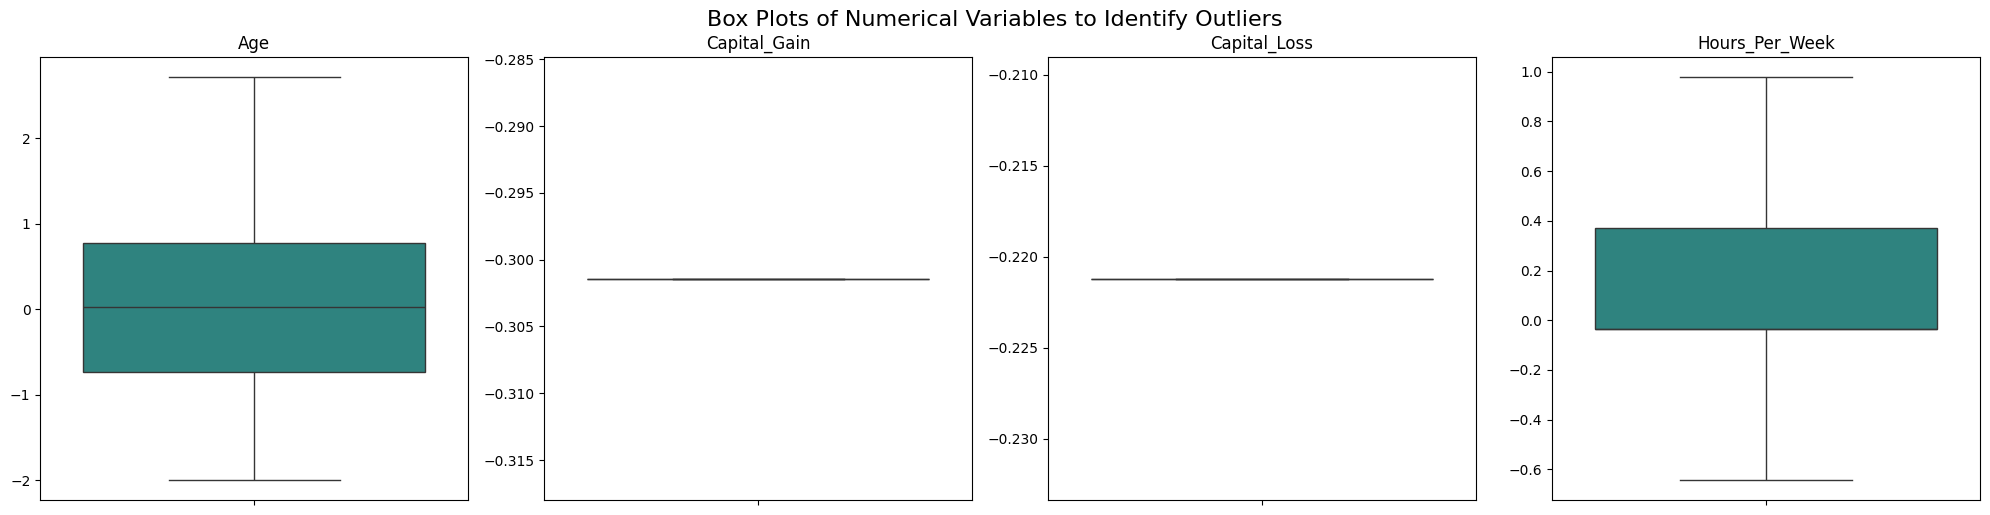

In [168]:
# distribution post outlier detection

num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [169]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,32561.0,1.274399e-15,1.000015e+00,-1.997057,-0.731682,0.028014,0.772168,2.711385
Workclass,32561.0,-3.513325e-16,1.000015e+00,-2.708437,-0.096185,-0.096185,-0.096185,3.629848
Education,32561.0,3.674807e-16,1.000015e+00,-2.161318,-0.477000,0.090500,0.395154,1.387059
Marital_Status,32561.0,1.767574e-17,1.000015e+00,-1.782444,-0.383467,-0.383467,0.919694,2.171796
Occupation,32561.0,8.641471e-17,1.000015e+00,-1.721497,-0.717356,0.060999,0.743428,1.564985
Sex,32561.0,-7.572198e-17,1.000015e+00,-1.422331,-1.422331,0.703071,0.703071,0.703071
Capital_Gain,32561.0,-3.014255e-01,0.000000e+00,-0.301425,-0.301425,-0.301425,-0.301425,-0.301425
Capital_Loss,32561.0,-2.212096e-01,5.551200e-17,-0.221210,-0.221210,-0.221210,-0.221210,-0.221210
Hours_Per_Week,32561.0,6.183134e-02,5.011340e-01,-0.643050,-0.035570,-0.035570,0.369416,0.976896
Income,32561.0,2.408096e-01,4.275815e-01,0.000000,0.000000,0.000000,0.000000,1.000000


In [170]:
x = df_eda.drop(columns=['Income'])
y = df_eda['Income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation with EDA & without scaling :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & without scaling :


,Model,Train Accuracy,Test Accuracy
0,GradientBoostingClassifier,0.8422,0.8434
1,XGBClassifier,0.8720,0.8408
2,AdaBoostClassifier,0.8218,0.8236
3,RandomForestClassifier,0.9575,0.8190
4,KNeighborsClassifier,0.8643,0.8171
5,SVC,0.8119,0.8075
6,VotingClassifier,0.8504,0.8035
7,DecisionTreeClassifier,0.9576,0.7746
8,LogisticRegression,0.7667,0.7663
9,BernoulliNB,0.7645,0.7629


In [171]:
#use scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Model evaluation with EDA & scaling :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Model evaluation with EDA & scaling :


,Model,Train Accuracy,Test Accuracy
0,GradientBoostingClassifier,0.8422,0.8434
1,XGBClassifier,0.8720,0.8408
2,AdaBoostClassifier,0.8218,0.8236
3,RandomForestClassifier,0.9575,0.8190
4,KNeighborsClassifier,0.8650,0.8138
5,SVC,0.8094,0.8042
6,VotingClassifier,0.8470,0.8002
7,DecisionTreeClassifier,0.9576,0.7746
8,LogisticRegression,0.7666,0.7662
9,BernoulliNB,0.7646,0.7629


#### Observation : XGBClassifier is best performing model with train_accuracy : 0.8936 & test_accuracy : 0.8759

In [172]:
XGBClassifier_model = models[8]

l_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.5],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 1.0],
    'reg_lambda': [1.0, 2.0]
}

x = df.drop(columns=['Income'])
y = df['Income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
grid_search = GridSearchCV(estimator=XGBClassifier_model, param_grid=l_param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train, y_train)

best_model = grid_search.best_estimator_
print("Best Hyperparameters for XGBClassifier model:", grid_search.best_params_)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best Hyperparameters for XGBClassifier model: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.5, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 1.0}


In [173]:
l_models = [best_model]
print("Model evaluation with EDA & scaling :")
EndToEndEvaluation(l_models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & scaling :


,Model,Train Accuracy,Test Accuracy
0,XGBClassifier,0.8795,0.8749


In [174]:
#dump the best performing model
joblib.dump(best_model, 'XGBClassifier_model.pkl')

['XGBClassifier_model.pkl']